# Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms

**Name:** Aashish Shrestha

**Course:** Advance Big Data and Data Mining (MSCS 634 -M50)

**Lab Assignment:** Lab 3 &ndash; Clustering Analysis Using K-Means and K-Medoids Algorithms


## About Lab 3

Clustering is *unsupervised*, which means the algorithm gets
no labels at all and has to find groups in the data on its own.

I use the **Wine dataset** (178 wines, 13 chemical measurements each, 3 real wine types) and
run two clustering methods on it:

- **K-Means** puts each cluster's center at the *average* of its members (a made-up point
  called a centroid).
- **K-Medoids** forces each cluster's center to be an *actual wine* from the data (called a
  medoid).

Both are set to find `k = 3` groups because the dataset is known to have 3 types. After
clustering I judge the results with two scores:

- **Silhouette Score** &ndash; how tight and well-separated the clusters are, on a scale
  from -1 to 1 (higher is better).
- **Adjusted Rand Index (ARI)** &ndash; how closely the discovered clusters match the real
  wine types, on a scale up to 1 (higher is better). The algorithm never sees these true
  types; I only use them at the end to grade the result.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import pairwise_distances

%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 5)

## Step 1: Load and prepare the dataset

I load the Wine data, look at it briefly, and then standardize it so every feature is on the
same scale.


In [ ]:
wine = load_wine()
X = wine.data
y = wine.target                    # true wine types (used only for the ARI score later)
feature_names = wine.feature_names
class_names = list(wine.target_names)

df = pd.DataFrame(X, columns=feature_names)
df["wine_type"] = y

print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Real wine types:", class_names)
df.head()

Samples: 178
Features: 13
Real wine types: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_type
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


A quick statistical summary of the features. The scales are all over the place: most columns sit in single or double digits, but **proline** climbs past 1000. If I left the data like this, that one big feature would dominate every distance calculation and the clustering would basically ignore the other 12 features. That is exactly why the next step (standardizing) matters.

In [ ]:
df[feature_names].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


The three wine types are reasonably balanced, so no group is tiny compared to the others.

class_0 (type 0): 59 wines
class_1 (type 1): 71 wines
class_2 (type 2): 48 wines


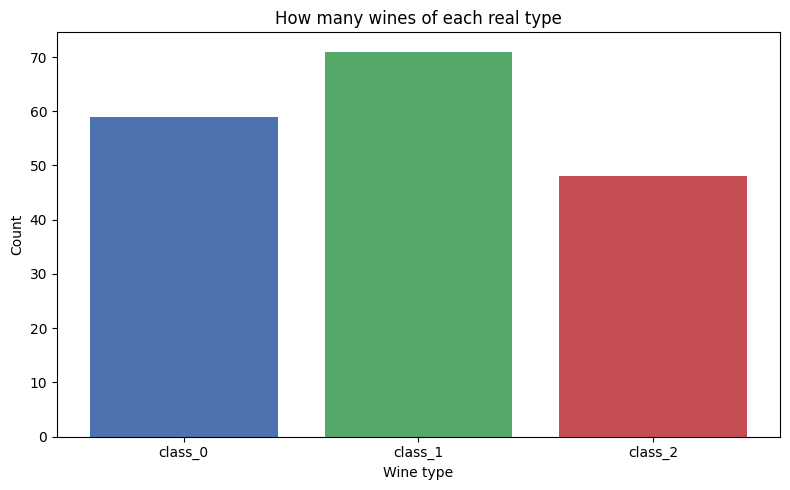

In [ ]:
counts = df["wine_type"].value_counts().sort_index()
for cls, n in counts.items():
    print(f"{class_names[cls]} (type {cls}): {n} wines")

plt.bar([class_names[i] for i in counts.index], counts.values,
        color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("How many wines of each real type")
plt.ylabel("Count")
plt.xlabel("Wine type")
plt.tight_layout()
plt.show()

### Standardizing with z-score normalization

Z-score standardizing rewrites every feature as *"how many standard deviations away from its
own average is this value"*. The formula is `(value - mean) / standard_deviation`. After this,
every feature has a mean of about 0 and a standard deviation of about 1, so no single feature
can bully the distance measurements. `StandardScaler` does this for me.


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Proof it worked: means near 0, standard deviations near 1
print("Mean of each feature after scaling (first 5):", np.round(X_scaled.mean(axis=0)[:5], 3))
print("Std  of each feature after scaling (first 5):", np.round(X_scaled.std(axis=0)[:5], 3))

Mean of each feature after scaling (first 5): [ 0.  0. -0. -0. -0.]
Std  of each feature after scaling (first 5): [1. 1. 1. 1. 1.]


## Step 2: K-Means clustering (k = 3)

K-Means starts with 3 guessed centers, assigns every wine to its nearest center, moves each
center to the average of the wines assigned to it, and repeats until things stop moving. I set
`n_init=10` so it tries 10 different starting points and keeps the best one, and `random_state=42`
so the result is the same on every run.


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-MEANS RESULTS")
print(f"  Silhouette Score      : {kmeans_sil:.4f}")
print(f"  Adjusted Rand Index   : {kmeans_ari:.4f}")

K-MEANS RESULTS
  Silhouette Score      : 0.2849
  Adjusted Rand Index   : 0.8975


## Step 3: K-Medoids clustering (k = 3)

There is no K-Medoids inside plain scikit-learn, and the usual add-on library
(`scikit-learn-extra`) does not work with the current NumPy version, so I wrote the algorithm
myself. It is short and follows the standard idea:

1. Pick 3 starting wines to act as medoids (spread out using a k-medoids++ style seeding).
2. Assign every wine to its nearest medoid.
3. Inside each group, swap the medoid for whichever wine in that group has the smallest total
   distance to its group-mates.
4. Repeat steps 2&ndash;3 until the medoids stop changing.

I run the whole thing 10 times from different starts and keep the version with the lowest total
distance, which is the same "try several starts" trick K-Means uses.


In [ ]:
def k_medoids(X, k=3, max_iter=300, n_init=10, random_state=42):
    """Simple K-Medoids (alternating version). Returns cluster labels and medoid row indices."""
    D = pairwise_distances(X, metric="euclidean")   # full distance table between all wines
    n = X.shape[0]
    rng = np.random.RandomState(random_state)
    best_medoids, best_labels, best_cost = None, None, np.inf

    for _ in range(n_init):
        # --- spread-out starting medoids (k-medoids++ style) ---
        medoids = [rng.randint(n)]
        for _ in range(1, k):
            nearest_dist_sq = np.min(D[:, medoids], axis=1) ** 2
            probs = nearest_dist_sq / nearest_dist_sq.sum()
            medoids.append(rng.choice(n, p=probs))
        medoids = np.array(medoids)

        # --- alternate: assign, then re-pick the best medoid per group ---
        for _ in range(max_iter):
            labels = np.argmin(D[:, medoids], axis=1)
            new_medoids = medoids.copy()
            for c in range(k):
                members = np.where(labels == c)[0]
                if len(members) == 0:
                    continue
                total_dist = D[np.ix_(members, members)].sum(axis=1)
                new_medoids[c] = members[np.argmin(total_dist)]
            if np.array_equal(new_medoids, medoids):
                break
            medoids = new_medoids

        # --- keep this run if it is the best so far ---
        labels = np.argmin(D[:, medoids], axis=1)
        cost = D[np.arange(n), medoids[labels]].sum()
        if cost < best_cost:
            best_cost, best_medoids, best_labels = cost, medoids, labels

    return best_labels, best_medoids


kmedoids_labels, medoid_indices = k_medoids(X_scaled, k=3)

kmedoids_sil = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("K-MEDOIDS RESULTS")
print(f"  Silhouette Score      : {kmedoids_sil:.4f}")
print(f"  Adjusted Rand Index   : {kmedoids_ari:.4f}")
print(f"  Medoid wine indices   : {medoid_indices}")

K-MEDOIDS RESULTS
  Silhouette Score      : 0.2676
  Adjusted Rand Index   : 0.7411
  Medoid wine indices   : [106 148  35]


## Step 4: Visualize and compare

The data lives in 13 dimensions, which nobody can picture. To draw it, I use **PCA** to squeeze
those 13 features down to the 2 directions that hold the most variation, then plot the wines on
those two axes. The clustering itself was still done on the full 13-dimensional data; PCA is only
for the picture.


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Variation captured by the 2 PCA axes:",
      np.round(pca.explained_variance_ratio_, 3),
      "=> total", round(pca.explained_variance_ratio_.sum(), 3))

# Centers in 2D:
#  - K-Means centroids are averaged points, so transform them through the same PCA
#  - K-Medoids medoids are real wines, so just grab their PCA coordinates
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)
kmedoids_centers_pca = X_pca[medoid_indices]

Variation captured by the 2 PCA axes: [0.362 0.192] => total 0.554


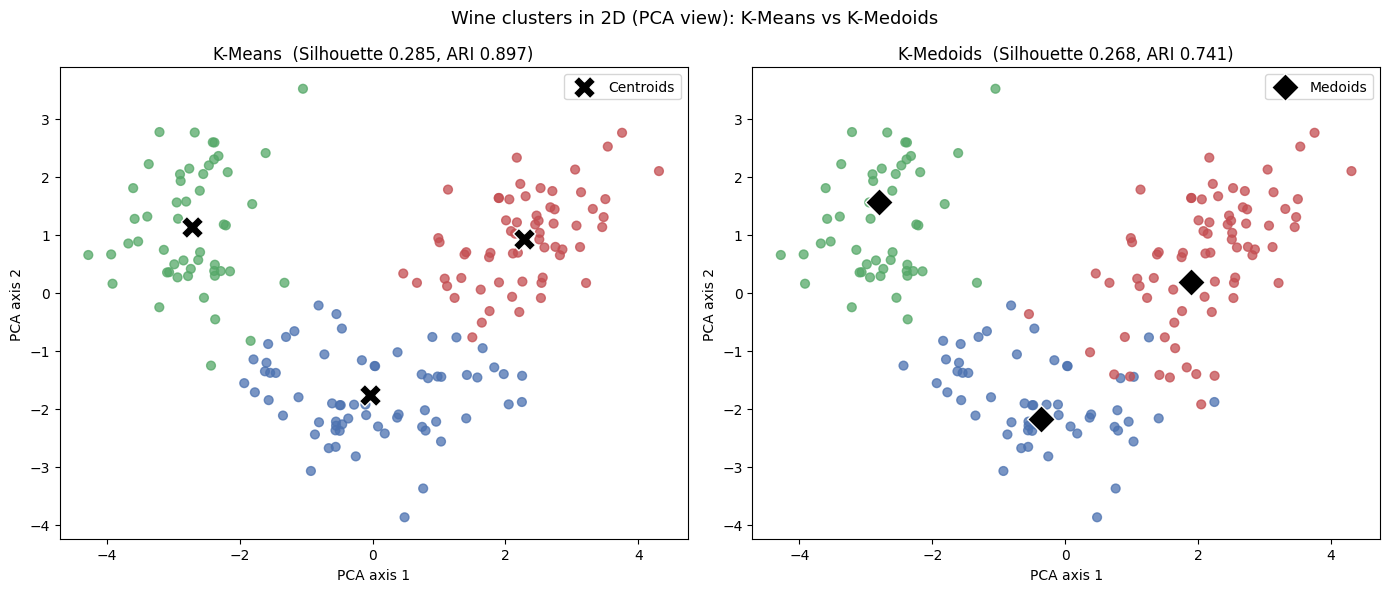

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = np.array(["#4C72B0", "#55A868", "#C44E52"])

# ---- K-Means ----
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=palette[kmeans_labels], s=40, alpha=0.75)
axes[0].scatter(kmeans_centers_pca[:, 0], kmeans_centers_pca[:, 1],
                c="black", marker="X", s=260, edgecolors="white", label="Centroids")
axes[0].set_title(f"K-Means  (Silhouette {kmeans_sil:.3f}, ARI {kmeans_ari:.3f})")
axes[0].set_xlabel("PCA axis 1")
axes[0].set_ylabel("PCA axis 2")
axes[0].legend()

# ---- K-Medoids ----
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=palette[kmedoids_labels], s=40, alpha=0.75)
axes[1].scatter(kmedoids_centers_pca[:, 0], kmedoids_centers_pca[:, 1],
                c="black", marker="D", s=200, edgecolors="white", label="Medoids")
axes[1].set_title(f"K-Medoids  (Silhouette {kmedoids_sil:.3f}, ARI {kmedoids_ari:.3f})")
axes[1].set_xlabel("PCA axis 1")
axes[1].set_ylabel("PCA axis 2")
axes[1].legend()

plt.suptitle("Wine clusters in 2D (PCA view): K-Means vs K-Medoids", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Side-by-side score summary
summary = pd.DataFrame({
    "Silhouette Score": [kmeans_sil, kmedoids_sil],
    "Adjusted Rand Index": [kmeans_ari, kmedoids_ari],
}, index=["K-Means", "K-Medoids"]).round(4)
summary

,Silhouette Score,Adjusted Rand Index
K-Means,0.2849,0.8975
K-Medoids,0.2676,0.7411


## Analysis and comparison

### Which method made better-defined clusters?
K-Means came out ahead on both scores. Its Silhouette was about **0.285** against **0.268** for
K-Medoids, so its groups were a touch tighter and better separated. The bigger gap was in the
ARI: **0.90** for K-Means versus **0.74** for K-Medoids. Because ARI checks how well the clusters
match the real wine types, this says K-Means recovered the true three-type structure much more
faithfully, even though it never got to see those types.

### Differences in cluster shapes and positions
On the PCA plots both methods split the wines into three groups sitting in roughly the same
regions, so the broad picture agrees. The clear difference is where the centers land. The K-Means
centroids sit right in the heart of each colored cloud, because a centroid is just the average of
its members. The K-Medoids centers are real wines, so they get nudged off-center toward wherever an
actual sample happens to be. That constraint also shows up at the borders: a handful of wines near
the edges get sorted into different groups by the two methods, and those disagreements are what
pulled the K-Medoids ARI down.

### When is each one preferable?
**K-Means** is the better pick when the clusters are roughly round and the data is fairly clean,
which fits the standardized Wine data well. It is fast and its centroids are easy averages. The
downside is that those averages get dragged around by extreme points.

**K-Medoids** shines when the data has outliers or noise. Its centers must be real samples and it
adds up plain distances instead of squared ones, so one weird point cannot yank a center far away.
It is also useful when you want each cluster's "representative" to be a genuine member of the
dataset, or when you are using a distance measure where averaging makes no sense. The costs are that
it is slower and, as seen here, it can do a little worse when the data is already clean and
well-behaved.

